In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import ROOT
import numpy as np
import mplhep as hep

import matplotlib.pyplot as plt


/home/thea/devel/dune-trigger/dune-trg-utilities/.venv/lib/python3.14/site-packages/ROOT/__init__.py:222: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(


# Plot MCTruth histograms saved by `plotting/make_mc_histograms.py`

In [3]:
hist_file = ROOT.TFile.Open("../data/mcthruth_histograms_radbkg_5467776.root")

## Collect histogram collection from the file

In [4]:
ke_by_gen_dir = hist_file['kinetic_energy_by_generator_name']
ke_by_pdg_dir = hist_file['kinetic_energy_by_pdg']

In [5]:
ke_by_gen_hists = { k.GetName():ke_by_gen_dir[k.GetName()] for k in ke_by_gen_dir.GetListOfKeys()}

for n, h in ke_by_gen_hists.items():
    print(n, h.Integral())
    

kinetic_energy 6590242042.0
Rn222ChainFromPo218GenInUpperMesh1x8x14 95316.0
Rn220ChainFromPb212GenInUpperMesh1x8x14 2435167.0
Kr85GenInLAr 176540521.0
Rn222ChainFromBi210GenInUpperMesh1x8x14 1924589.0
U238ChainGenInAnode 67953632.0
K40GenInCathode 11609397.0
K42From42ArGenInUpperMesh1x8x14 114732.0
Th232ChainGenInCathode 179536645.0
CavernNGammasAtLAr1x8x14 4997.0
Rn222ChainRn222GenInLAr 1535562.0
U238ChainGenInCathode 150627930.0
K40GenInAnode 5239631.0
Rn220ChainPb212GenInLAr 1383542.0
foamGammasAtLAr1x8x14 173704237.0
Rn222ChainFromPb214GenInUpperMesh1x8x14 1073474.0
K42From42ArGenInLAr 33421.0
Rn222ChainGenInPDS 65170.0
Ar42GenInLAr 141192.0
CavernwallGammasAtLAr1x8x14 4173625362.0
Rn222ChainPb210GenInLAr 1087454.0
Ar39GenInLAr 1549163179.0
Rn222ChainPb214GenInLAr 2629800.0
Rn222ChainFromPb210GenInUpperMesh1x8x14 2530266.0
Rn222ChainPo218GenInLAr 1422290.0
CavernwallNeutronsAtLAr1x8x14 9993.0
Rn222ChainFromBi214GenInUpperMesh1x8x14 2552071.0
CryostatNGammasAtLAr1x8x14 4996.0
Th232C

In [6]:
ke_by_gen_hists_sorted = sorted(ke_by_gen_hists.items(), key=lambda x: x[1].Integral(), reverse=True)

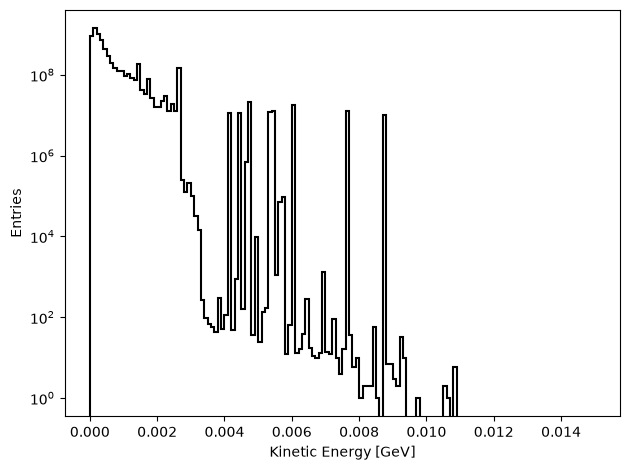

In [26]:
n_top = 30
top_bkg = dict(ke_by_gen_hists_sorted[1:1+n_top])

fig, ax = plt.subplots()
hep.histplot(ke_by_gen_hists_sorted[0][1], ax=ax, color='k', yerr=False)

ax.set_yscale('log')
ax.set_ylabel('Entries')
ax.set_xlabel('Kinetic Energy [GeV]')
fig.tight_layout()

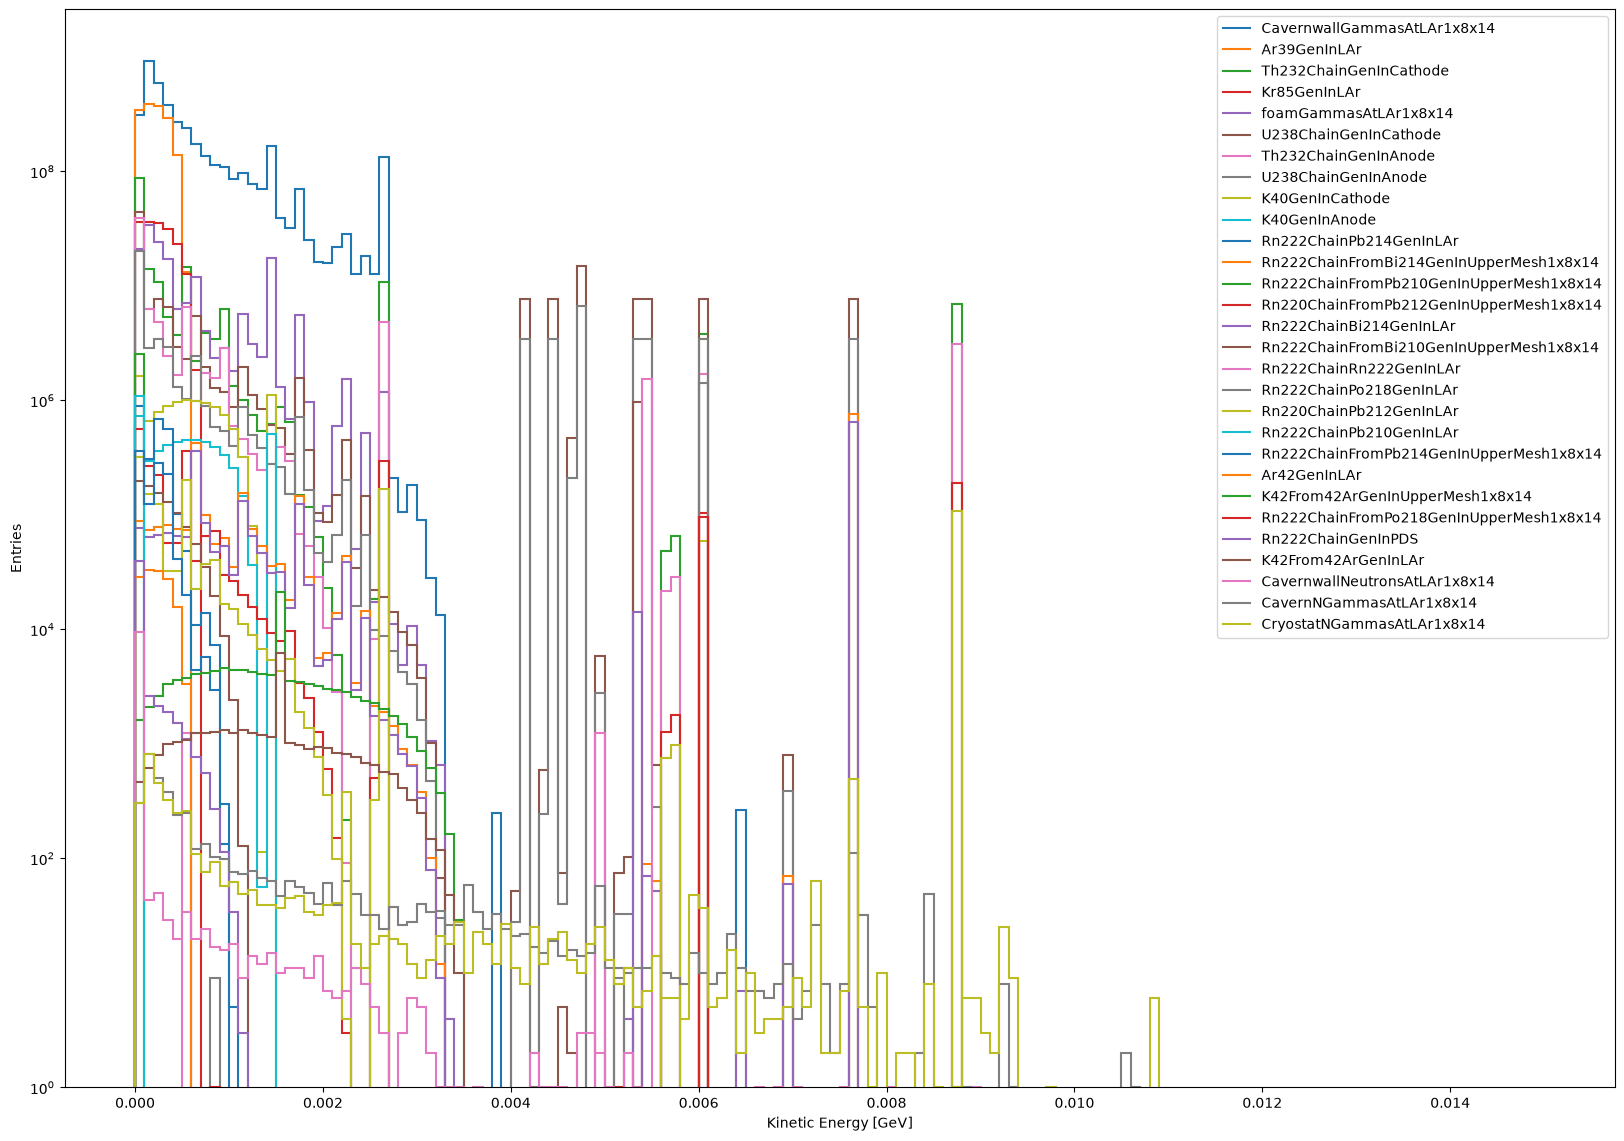

In [28]:
fig, ax = plt.subplots(figsize=(20, 14))

for n, h in top_bkg.items():
    hep.histplot(h, ax=ax, label=n, yerr=False)
    
ax.set_yscale('log')
ax.set_ylabel('Entries')
ax.set_xlabel('Kinetic Energy [GeV]')
ax.set_ylim(ymin=1)
ax.legend()

In [24]:
ke_by_pdg_hists = { k.GetName():ke_by_pdg_dir[k.GetName()] for k in ke_by_pdg_dir.GetListOfKeys()}

for n, h in ke_by_pdg_hists.items():
    print(n, h.Integral())

kinetic_energy 6590242042.0
He4 110330291.0
eminus 1956433372.0
eplus 7704.0
gamma 4523460682.0


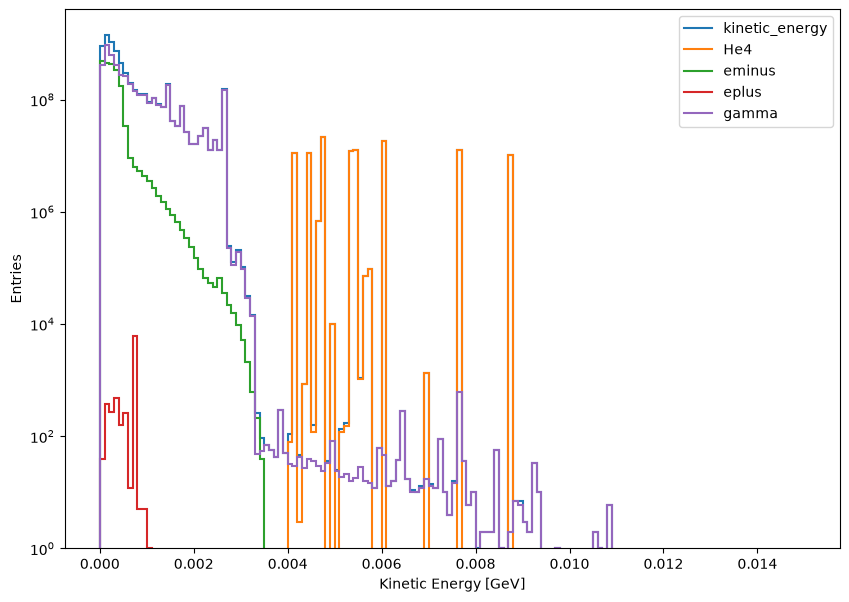

In [25]:
fig, ax = plt.subplots(figsize=(10, 7))

for n, h in ke_by_pdg_hists.items():
    hep.histplot(h, ax=ax, label=n, yerr=False)
    
ax.set_yscale('log')
ax.set_ylabel('Entries')
ax.set_xlabel('Kinetic Energy [GeV]')
ax.set_ylim(ymin=1)
ax.legend()